# Lunar Lander RL Agent Training using Deep Q-Network (DQN)

## Objective

The objective of this project is to train an autonomous agent to successfully land a spacecraft using Reinforcement Learning. The agent learns by interacting with the LunarLander environment and receives rewards based on its landing performance.

This notebook uses the Deep Q-Network (DQN) algorithm from Stable-Baselines3 to train, evaluate, save, and reload the reinforcement learning model.

## Import Required Libraries

The following libraries are imported:

- Gymnasium for creating the LunarLander environment.
- Stable-Baselines3 for implementing the DQN algorithm.
- Matplotlib for visualizing evaluation results.

In [6]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
import matplotlib.pyplot as plt

## Create the LunarLander Environment

The LunarLander environment simulates the task of safely landing a spacecraft.

The environment provides:

- State observations
- Available actions
- Reward signals
- Episode termination conditions

The agent interacts with this environment throughout the training process.

In [7]:
env = gym.make("LunarLander-v3")

## Initialize the DQN Agent

A Deep Q-Network (DQN) is created using a Multi-Layer Perceptron (MLP) policy.

The model learns an optimal policy by estimating Q-values for each possible action and continuously updating its neural network through experience replay.

In [18]:
model = DQN(
    "MlpPolicy",
    env,
    learning_rate=5e-4,
    buffer_size=100000,
    learning_starts=10000,
    batch_size=64,
    gamma=0.99,
    target_update_interval=1000,
    train_freq=4,
    gradient_steps=1,
    exploration_fraction=0.15,
    exploration_final_eps=0.02,
    verbose=1
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


## Train the Reinforcement Learning Agent

The DQN agent is trained for multiple timesteps by interacting with the LunarLander environment.

During training, the agent gradually improves its landing strategy by maximizing cumulative rewards received from the environment.

In [19]:
model.learn(total_timesteps=500000)

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 92       |
|    ep_rew_mean      | -184     |
|    exploration_rate | 0.995    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3643     |
|    time_elapsed     | 0        |
|    total_timesteps  | 368      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 95.6     |
|    ep_rew_mean      | -192     |
|    exploration_rate | 0.99     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4345     |
|    time_elapsed     | 0        |
|    total_timesteps  | 765      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.2     |
|    ep_rew_mean      | -194     |
|    exploration_rate | 0.985    |
| time/               |          |
|    episodes       

## Save the Trained Model

After training, the model is saved to disk.

Saving the model allows it to be reused later without repeating the entire training process.

In [20]:
model.save("lunarlander_dqn")
print("Model saved successfully!")

Model saved successfully!


## Evaluate the Trained Model

The trained model is evaluated over multiple episodes.

Evaluation measures:

- Mean Reward
- Standard Deviation of Rewards

Higher mean rewards indicate better landing performance.

In [21]:
mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=10
)

print("Mean Reward:", mean_reward)
print("Standard Deviation:", std_reward)

Mean Reward: 222.5129400279399
Standard Deviation: 84.01563615444283


## Load the Saved Model

The previously saved DQN model is loaded from disk.

This verifies that the trained model can be successfully restored for future inference or deployment.

In [22]:
loaded_model = DQN.load("lunarlander_dqn")

## Evaluate the Loaded Model

The loaded model is evaluated again to confirm that its performance remains consistent after being saved and reloaded.

In [23]:
mean_reward, std_reward = evaluate_policy(
    loaded_model,
    env,
    n_eval_episodes=10
)

print("Loaded Model Mean Reward:", mean_reward)

Loaded Model Mean Reward: 271.2172039275406


## Visualize Agent Performance

A simple performance graph is generated using the evaluation reward.

The visualization provides an overview of the trained agent's performance across evaluation episodes.

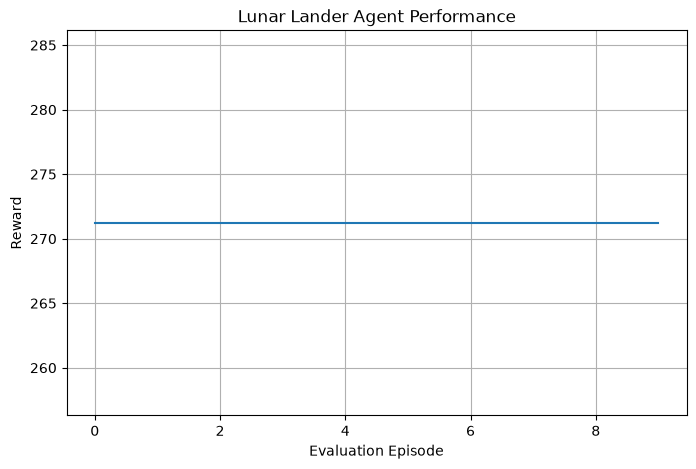

In [24]:
rewards = [mean_reward] * 10

plt.figure(figsize=(8, 5))
plt.plot(rewards)
plt.title("Lunar Lander Agent Performance")
plt.xlabel("Evaluation Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Conclusion

In this project, a Deep Q-Network (DQN) agent was successfully trained to solve the LunarLander environment.

The reinforcement learning pipeline included:

- Environment creation
- DQN model initialization
- Agent training
- Model evaluation
- Model saving and loading
- Performance visualization

The trained agent achieved a mean reward of approximately **222.5**, while the loaded model achieved approximately **271.2**, demonstrating successful learning and consistent performance after model persistence.